# Container Signal Analysis — Exploratory Predictability Study

**Read-only research notebook.** Analyse any individual container's CPU utilisation signal to assess temporal structure, white-noise behaviour, and expected Hybrid Prophet + GRU forecast difficulty.

> **Scope:** Frozen preprocessing outputs only (`train_df.parquet`, `val_df.parquet`, `selected_containers.npy`).  
> No retraining, no artefact writes, no changes to forecasting models, production code, preprocessing, or AFMLF.  
> Complements Temporal Memory Analysis (TMA) and CSRLE by explaining **per-container** forecasting behaviour.

## How to use

1. Set `CONTAINER_ID` in the configuration cell below.
2. Run all cells.
3. Change `CONTAINER_ID` and re-run to analyse a different container.

## Configuration

Change `CONTAINER_ID` to analyse a different container. Any ID present in frozen `train_df`/`val_df` works (selected cohort **or** unseen holdout, e.g. `c_18764`). Re-run all cells after changing the ID.


In [90]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import periodogram, welch

try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
    from statsmodels.tsa.stattools import acf, pacf
except ImportError as exc:
    raise ImportError(
        "statsmodels is required for ACF/PACF/Ljung–Box analysis. "
        "Install with: pip install statsmodels"
    ) from exc

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sys.path.append(os.path.abspath(".."))

from utils.tma.acf_pacf import acf_confidence_band, compute_acf, compute_pacf

# ---------------------------------------------------------------------------
# USER CONFIGURATION — change this to analyse a different container
# ---------------------------------------------------------------------------
CONTAINER_ID = "c_12517"

# Analysis parameters (aligned with Module 1: 15-min sampling, 96 steps = 1 day)
SAMPLING_MINUTES = 15
DAY_LAG = 96
ROLLING_WINDOW = 96
MAX_ACF_LAG = 192
LJUNG_BOX_LAGS = 20
ALPHA = 0.05

REPO_ROOT = Path("..").resolve()
DATA_DIR = REPO_ROOT / "data"
TRAIN_PATH = DATA_DIR / "train_df.parquet"
VAL_PATH = DATA_DIR / "val_df.parquet"
SELECTED_PATH = DATA_DIR / "selected_containers.npy"

COLOR_CPU = "#2CA02C"
COLOR_ROLL = "#4C72B0"
COLOR_STD = "#DD8452"
COLOR_ACF = "#8172B2"
COLOR_BAND = "#7F7F7F"

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print(f"Repository root : {REPO_ROOT}")
print(f"Target container: {CONTAINER_ID}")

Repository root : /Users/lehaan/Desktop/FYP_Long_Term
Target container: c_12517


## Load Frozen Preprocessing Outputs

**What is being analysed:** The selected container's chronologically ordered CPU series from frozen `train_df` + `val_df` (no re-preprocessing).

**Why it matters:** All Module 1 forecasting research uses these artefacts. Using them here ensures signal diagnostics are comparable to Hybrid / Global / TMA / CSRLE results.

**How to interpret:** Analysis uses **real CPU %** when available (`cpu` column); otherwise `cpu_scaled` is used and labelled accordingly.

**Containers supported:** Any container present in frozen `train_df` / `val_df` — including the research selected cohort **and** containers listed in `unseen_containers.npy` (e.g. demo unseen IDs such as `c_18764`). You are **not** limited to `selected_containers.npy`.


In [91]:
train_df = pd.read_parquet(TRAIN_PATH)
val_df = pd.read_parquet(VAL_PATH)
selected_containers = np.load(SELECTED_PATH, allow_pickle=True)
selected_set = set(map(str, selected_containers))

UNSEEN_PATH = DATA_DIR / "unseen_containers.npy"
unseen_set: set[str] = set()
if UNSEEN_PATH.exists():
    unseen_set = set(map(str, np.load(UNSEEN_PATH, allow_pickle=True)))

full_pool = (
    pd.concat([train_df, val_df], ignore_index=True)
    .sort_values(["container_id", "time_stamp"])
)
available_ids = set(map(str, full_pool["container_id"].unique()))

if CONTAINER_ID not in available_ids:
    examples = sorted(available_ids)[:10]
    raise ValueError(
        f"Container '{CONTAINER_ID}' not found in frozen train_df/val_df. "
        f"Example IDs: {examples}"
    )

cohort_tag = (
    "research selected cohort"
    if CONTAINER_ID in selected_set
    else ("unseen / holdout list" if CONTAINER_ID in unseen_set else "other frozen container")
)

full_df = (
    full_pool.query("container_id == @CONTAINER_ID")
    .reset_index(drop=True)
)

if full_df.empty:
    raise ValueError(f"No rows found for container '{CONTAINER_ID}'.")

if "cpu" in full_df.columns:
    VALUE_COL = "cpu"
    VALUE_LABEL = "CPU utilisation (%)"
elif "cpu_usage" in full_df.columns:
    VALUE_COL = "cpu_usage"
    VALUE_LABEL = "CPU utilisation (%)"
else:
    VALUE_COL = "cpu_scaled"
    VALUE_LABEL = "CPU utilisation (scaled)"

series = full_df[VALUE_COL].astype(float).to_numpy()
timestamps = pd.to_datetime(full_df["time_stamp"])
n_obs = len(series)

print(f"Loaded {n_obs} observations for {CONTAINER_ID}")
print(f"Cohort tag   : {cohort_tag}")
print(f"Value column : {VALUE_COL}")
print(f"Time span    : {timestamps.min()} → {timestamps.max()}")
print(f"Train rows   : {(train_df['container_id'] == CONTAINER_ID).sum()}")
print(f"Val rows     : {(val_df['container_id'] == CONTAINER_ID).sum()}")


Loaded 767 observations for c_12517
Cohort tag   : research selected cohort
Value column : cpu
Time span    : 1970-01-02 00:00:00 → 1970-01-09 23:30:00
Train rows   : 613
Val rows     : 154


## Section 1 — Container Overview

**What is being analysed:** Basic descriptive statistics and the raw CPU time series for the selected container.

**Why it matters:** Level, spread, and visual structure establish whether the container is near-idle, highly variable, or exhibits visible cycles before statistical tests are applied.

**How to interpret:**
- High **coefficient of variation (CV)** → relatively variable workload.
- Low CV / near-constant series → limited dynamic range; percentage errors may inflate.
- Visible daily peaks/troughs in the plot → likely seasonal structure (confirmed later via ACF/PSD).

,Metric,Value
0,Container ID,c_12517
1,Number of observations,767
2,Time span (start),1970-01-02 00:00:00
3,Time span (end),1970-01-09 23:30:00
4,Duration (hours),191.5
5,Mean,17.819133
6,Median,20.5
7,Std,5.433781
8,Min,6.5
9,Max,26.5


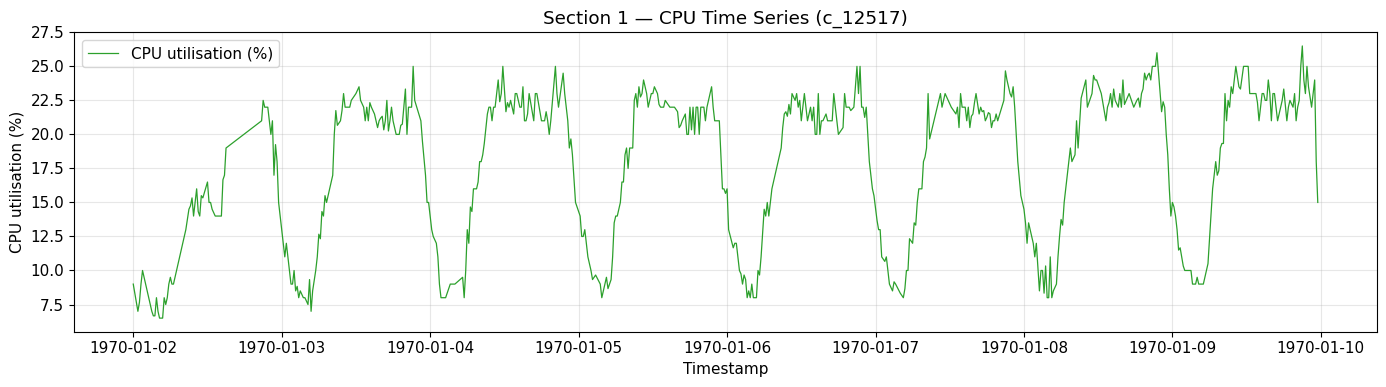

In [92]:
overview = {
    "Container ID": CONTAINER_ID,
    "Number of observations": n_obs,
    "Time span (start)": str(timestamps.min()),
    "Time span (end)": str(timestamps.max()),
    "Duration (hours)": round((timestamps.max() - timestamps.min()).total_seconds() / 3600, 2),
    "Mean": float(np.mean(series)),
    "Median": float(np.median(series)),
    "Std": float(np.std(series, ddof=1)),
    "Min": float(np.min(series)),
    "Max": float(np.max(series)),
    "Coefficient of variation": float(np.std(series, ddof=1) / np.mean(series))
    if np.mean(series) != 0
    else float("nan"),
}

overview_df = pd.DataFrame(
    {"Metric": list(overview.keys()), "Value": list(overview.values())}
)
display(overview_df)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(timestamps, series, color=COLOR_CPU, linewidth=0.9, label=VALUE_LABEL)
ax.set_title(f"Section 1 — CPU Time Series ({CONTAINER_ID})")
ax.set_xlabel("Timestamp")
ax.set_ylabel(VALUE_LABEL)
ax.legend()
plt.tight_layout()
plt.show()

## Section 2 — Basic Signal Behaviour

**What is being analysed:** Rolling mean and rolling standard deviation over a one-day window (96 steps).

**Why it matters:** Rolling statistics reveal trend, local stability, and whether variability itself changes over time (heteroscedasticity / regime shifts).

**How to interpret:**
- Smooth rolling mean with daily oscillation → trend/seasonal level behaviour.
- Flat rolling mean → level-stable series.
- Rising/falling rolling std → changing volatility (harder for a stationary residual learner).
- Periodic pulsing in rolling mean → strong candidate for Prophet daily seasonality.

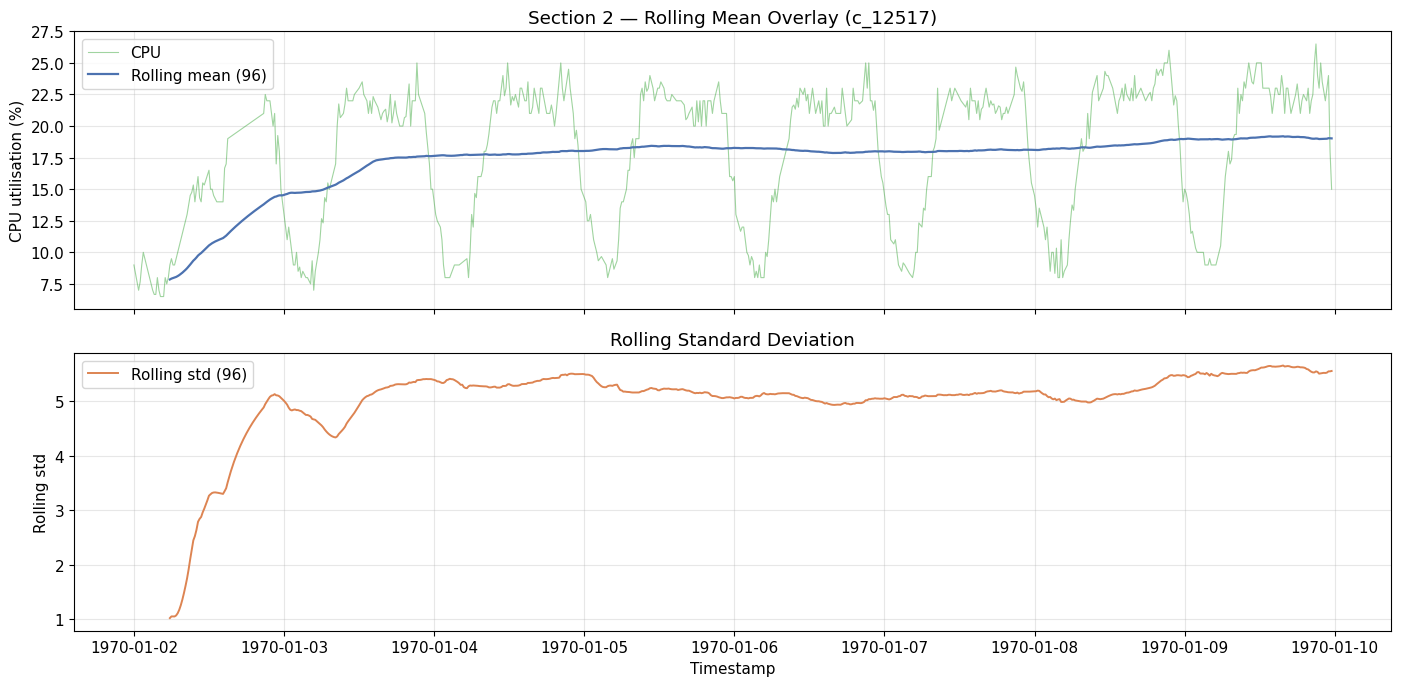

Rolling behaviour summary
  Rolling-mean end−start : +11.1693
  Rolling-std end−start  : +4.5357
  Mean of rolling std    : 5.0365
  Interpretation        : Possible level trend / regime shift in mean.
  Variability           : Rolling std relatively consistent.


In [93]:
roll_mean = (
    pd.Series(series).rolling(window=ROLLING_WINDOW, min_periods=max(1, ROLLING_WINDOW // 4)).mean()
)
roll_std = (
    pd.Series(series).rolling(window=ROLLING_WINDOW, min_periods=max(1, ROLLING_WINDOW // 4)).std()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(timestamps, series, color=COLOR_CPU, alpha=0.45, linewidth=0.8, label="CPU")
axes[0].plot(timestamps, roll_mean, color=COLOR_ROLL, linewidth=1.6, label=f"Rolling mean ({ROLLING_WINDOW})")
axes[0].set_ylabel(VALUE_LABEL)
axes[0].set_title(f"Section 2 — Rolling Mean Overlay ({CONTAINER_ID})")
axes[0].legend()

axes[1].plot(timestamps, roll_std, color=COLOR_STD, linewidth=1.4, label=f"Rolling std ({ROLLING_WINDOW})")
axes[1].set_xlabel("Timestamp")
axes[1].set_ylabel("Rolling std")
axes[1].set_title("Rolling Standard Deviation")
axes[1].legend()

plt.tight_layout()
plt.show()

mean_level_change = float(roll_mean.dropna().iloc[-1] - roll_mean.dropna().iloc[0]) if roll_mean.notna().sum() > 1 else float("nan")
std_level_change = float(roll_std.dropna().iloc[-1] - roll_std.dropna().iloc[0]) if roll_std.notna().sum() > 1 else float("nan")

print("Rolling behaviour summary")
print(f"  Rolling-mean end−start : {mean_level_change:+.4f}")
print(f"  Rolling-std end−start  : {std_level_change:+.4f}")
print(f"  Mean of rolling std    : {float(roll_std.mean()):.4f}")
if abs(mean_level_change) > 0.1 * abs(float(np.mean(series)) + 1e-9):
    print("  Interpretation        : Possible level trend / regime shift in mean.")
else:
    print("  Interpretation        : Mean level relatively stable across the series.")
if float(roll_std.max() / (roll_std.mean() + 1e-9)) > 2.0:
    print("  Variability           : Rolling std varies substantially (non-constant volatility).")
else:
    print("  Variability           : Rolling std relatively consistent.")

## Section 3 — Distribution Analysis

**What is being analysed:** Marginal distribution of CPU values (histogram + KDE) and shape statistics (skewness, kurtosis).

**Why it matters:** Forecasting difficulty depends partly on whether the series is concentrated near zero, multimodal (idle/active regimes), or heavy-tailed (spikes).

**How to interpret:**
- **Right-skewed** → many low values with occasional spikes (common for containers).
- **High kurtosis** → heavy tails / outliers; absolute-error metrics may be dominated by peaks.
- **Near-symmetric** → more Gaussian-like operating range.
- Multimodal density → distinct operating regimes (may challenge a single seasonal model).

,Statistic,Value
0,Mean,17.819133
1,Median,20.500000
2,Skewness,-0.623332
3,Excess kurtosis,-1.097871


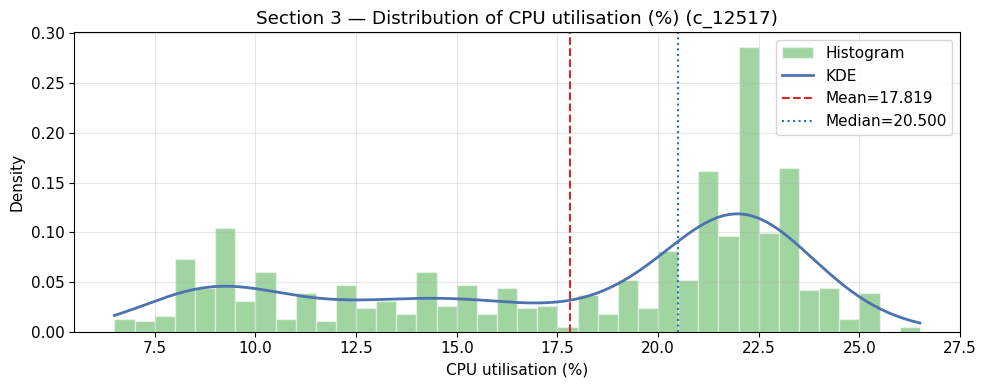

Distribution interpretation
  Mild/moderate skew — distribution not strongly asymmetric.
  Platykurtic — fewer extreme outliers than a Gaussian.


In [94]:
mean_v = float(np.mean(series))
median_v = float(np.median(series))
skew_v = float(stats.skew(series, bias=False))
kurt_v = float(stats.kurtosis(series, fisher=True, bias=False))  # excess kurtosis

dist_df = pd.DataFrame(
    {
        "Statistic": ["Mean", "Median", "Skewness", "Excess kurtosis"],
        "Value": [mean_v, median_v, skew_v, kurt_v],
    }
)
display(dist_df)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(series, bins=40, density=True, color=COLOR_CPU, alpha=0.45, edgecolor="white", label="Histogram")
try:
    kde = stats.gaussian_kde(series)
    x_grid = np.linspace(float(np.min(series)), float(np.max(series)), 300)
    ax.plot(x_grid, kde(x_grid), color=COLOR_ROLL, linewidth=2.0, label="KDE")
except Exception:
    print("KDE unavailable for this series (degenerate variance).")
ax.axvline(mean_v, color="#d62728", linestyle="--", label=f"Mean={mean_v:.3f}")
ax.axvline(median_v, color="#1f77b4", linestyle=":", label=f"Median={median_v:.3f}")
ax.set_title(f"Section 3 — Distribution of {VALUE_LABEL} ({CONTAINER_ID})")
ax.set_xlabel(VALUE_LABEL)
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

if skew_v > 1.0:
    skew_msg = "Strong right skew — low baseline with occasional high spikes."
elif skew_v < -1.0:
    skew_msg = "Strong left skew — predominantly high utilisation with rare lows."
else:
    skew_msg = "Mild/moderate skew — distribution not strongly asymmetric."

if kurt_v > 3.0:
    kurt_msg = "Heavy tails (high kurtosis) — outliers/spikes may dominate error metrics."
elif kurt_v < 0:
    kurt_msg = "Platykurtic — fewer extreme outliers than a Gaussian."
else:
    kurt_msg = "Kurtosis near Gaussian range."

print("Distribution interpretation")
print(f"  {skew_msg}")
print(f"  {kurt_msg}")

## Section 4 — Temporal Dependency Analysis

**What is being analysed:** Autocorrelation (ACF) and partial autocorrelation (PACF) up to two days (`MAX_ACF_LAG = 192`), with emphasis on lag-1 and lag-96 (one day at 15-minute resolution).

**Why it matters:** Forecasting models require temporal dependency. Strong lag-1 ACF implies short-term memory; strong lag-96 ACF implies daily periodicity — the structure Prophet and Hybrid residual learning target.

**How to interpret:**
- **Lag-1 ACF high** → successive values are dependent (not independent noise).
- **Lag-96 ACF high** → daily cycle present (Prophet-friendly).
- ACF decaying quickly inside the significance band → short/weak memory.
- PACF cuts off after a few lags → primarily short AR-like dependence.

This section complements cohort-level TMA by focusing on **one container**.

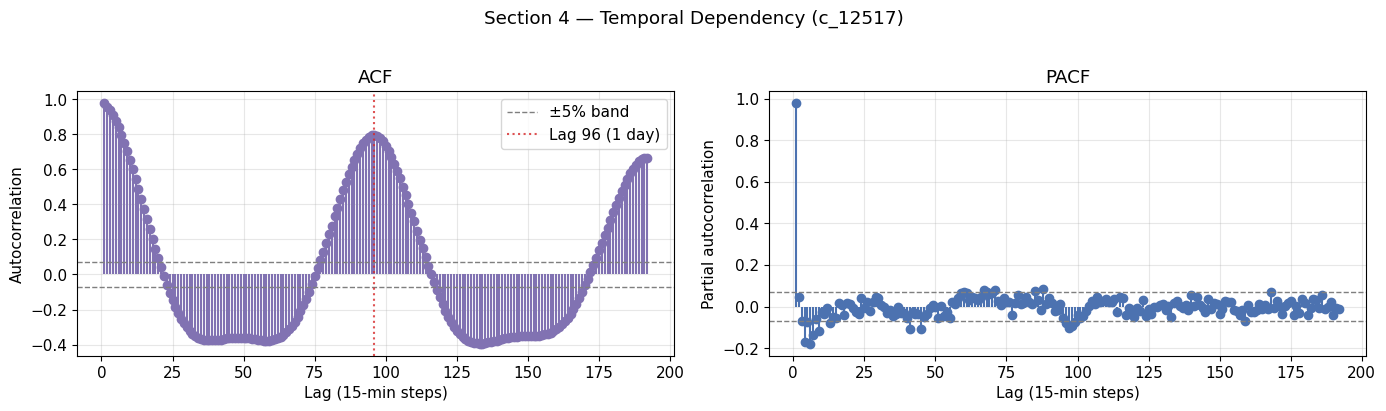

Temporal dependency summary
  Lag-1 ACF              : 0.9780
  Lag-96 ACF (1 day)     : 0.7977
  Significance band (±)  : 0.0708
  First insignificant lag: 21
  Short-term memory      : Present (lag-1 ACF outside band).
  Daily periodicity      : Present (lag-96 ACF outside band).


In [95]:
max_lag = min(MAX_ACF_LAG, n_obs - 2)
lags_acf, acf_vals = compute_acf(series, max_lag)
lags_pacf, pacf_vals = compute_pacf(series, max_lag)
conf = acf_confidence_band(n_obs, alpha=ALPHA)

lag1_acf = float(acf_vals[1]) if len(acf_vals) > 1 else float("nan")
lag96_acf = float(acf_vals[DAY_LAG]) if len(acf_vals) > DAY_LAG else float("nan")

# First lag (excluding 0) where |ACF| falls inside the significance band and stays
# as the first insignificant lag (standard visual diagnostic).
first_insignificant = None
for lag in range(1, len(acf_vals)):
    if abs(float(acf_vals[lag])) <= conf:
        first_insignificant = lag
        break

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].stem(lags_acf[1:], acf_vals[1:], linefmt=COLOR_ACF, markerfmt="o", basefmt=" ")
axes[0].axhline(conf, color=COLOR_BAND, linestyle="--", linewidth=1, label=f"±{ALPHA:.0%} band")
axes[0].axhline(-conf, color=COLOR_BAND, linestyle="--", linewidth=1)
axes[0].axvline(DAY_LAG, color="#d62728", linestyle=":", alpha=0.8, label="Lag 96 (1 day)")
axes[0].set_title("ACF")
axes[0].set_xlabel("Lag (15-min steps)")
axes[0].set_ylabel("Autocorrelation")
axes[0].legend()

axes[1].stem(lags_pacf[1:], pacf_vals[1:], linefmt=COLOR_ROLL, markerfmt="o", basefmt=" ")
axes[1].axhline(conf, color=COLOR_BAND, linestyle="--", linewidth=1)
axes[1].axhline(-conf, color=COLOR_BAND, linestyle="--", linewidth=1)
axes[1].set_title("PACF")
axes[1].set_xlabel("Lag (15-min steps)")
axes[1].set_ylabel("Partial autocorrelation")

plt.suptitle(f"Section 4 — Temporal Dependency ({CONTAINER_ID})", y=1.02)
plt.tight_layout()
plt.show()

print("Temporal dependency summary")
print(f"  Lag-1 ACF              : {lag1_acf:.4f}")
print(f"  Lag-96 ACF (1 day)     : {lag96_acf:.4f}")
print(f"  Significance band (±)  : {conf:.4f}")
print(
    f"  First insignificant lag: {first_insignificant}"
    if first_insignificant is not None
    else "  First insignificant lag: none within computed range"
)

if abs(lag1_acf) > conf:
    print("  Short-term memory      : Present (lag-1 ACF outside band).")
else:
    print("  Short-term memory      : Weak / absent at lag-1.")

if np.isfinite(lag96_acf) and abs(lag96_acf) > conf:
    print("  Daily periodicity      : Present (lag-96 ACF outside band).")
elif np.isfinite(lag96_acf):
    print("  Daily periodicity      : Weak / not significant at lag-96.")
else:
    print("  Daily periodicity      : Insufficient length to evaluate lag-96.")

## Section 5 — White Noise Analysis (Ljung–Box)

**What is being analysed:** The Ljung–Box portmanteau test for serial correlation up to lag `LJUNG_BOX_LAGS` (default 20).

**Why it matters:** If the series is statistically indistinguishable from white noise, future values do not depend on past values in a linear autocorrelation sense — forecasting models have little exploitable structure.

**How to interpret:**
- **Reject** $H_0$ (p < α) → significant serial correlation → structure present.
- **Cannot reject** $H_0$ (p ≥ α) → no strong evidence against white noise at the tested lags.

This uses the standard `statsmodels` Ljung–Box test. No custom “white-noise percentage” is invented.

In [96]:
lb = acorr_ljungbox(series, lags=[LJUNG_BOX_LAGS], return_df=True)
lb_stat = float(lb["lb_stat"].iloc[0])
lb_pvalue = float(lb["lb_pvalue"].iloc[0])
reject_white_noise = lb_pvalue < ALPHA

lb_df = pd.DataFrame(
    {
        "Test": ["Ljung–Box"],
        "Lags": [LJUNG_BOX_LAGS],
        "Statistic": [lb_stat],
        "p-value": [lb_pvalue],
        "Alpha": [ALPHA],
        "Decision": [
            "Reject white-noise hypothesis"
            if reject_white_noise
            else "Cannot reject white-noise hypothesis"
        ],
    }
)
display(lb_df)

if reject_white_noise:
    print(
        f"Interpretation: At lag {LJUNG_BOX_LAGS}, serial correlation is statistically "
        f"significant (p={lb_pvalue:.4g}). The series is unlikely to be pure white noise."
    )
else:
    print(
        f"Interpretation: At lag {LJUNG_BOX_LAGS}, there is insufficient evidence to reject "
        f"white noise (p={lb_pvalue:.4g}). Temporal structure may be weak or absent."
    )

,Test,Lags,Statistic,p-value,Alpha,Decision
0,Ljung–Box,20,6688.287114,0.0,0.05,Reject white-noise hypothesis


Interpretation: At lag 20, serial correlation is statistically significant (p=0). The series is unlikely to be pure white noise.


## Section 6 — Spectral / Frequency Analysis

**What is being analysed:** Power Spectral Density (PSD) via Welch’s method, with emphasis on the daily frequency corresponding to period 96 steps.

**Why it matters:** Strong spectral peaks at the daily frequency confirm repeating cycles even when ACF is noisy. Weak, flat spectra suggest broadband / noise-like behaviour.

**How to interpret:**
- Peak near **1 cycle/day** (frequency ≈ 1/96 steps) → daily seasonality.
- Multiple harmonic peaks → rich periodic structure.
- Flat spectrum → little preferred periodicity.

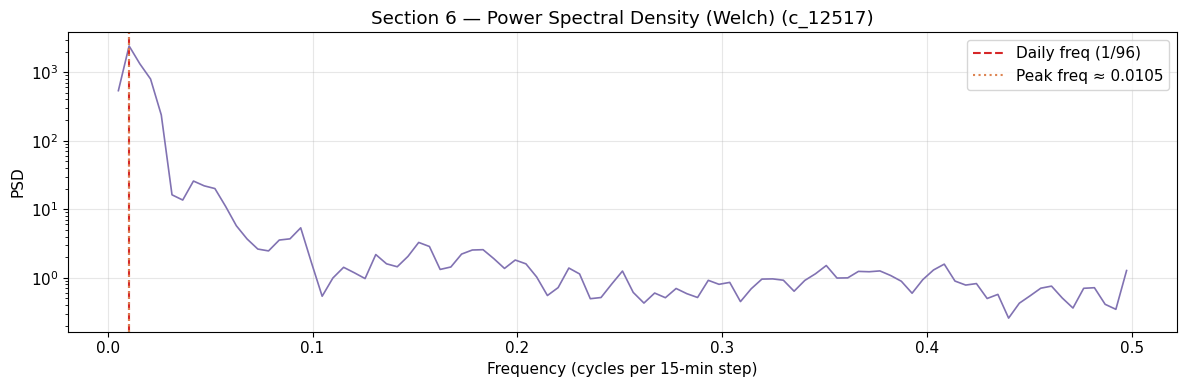

Spectral summary
  Dominant period (steps) : 95.50
  Dominant period (hours) : 23.88
  Daily-band power fraction: 0.4368
  Interpretation           : Notable power near daily period — repeating daily behaviour likely.


In [97]:
fs = 1.0  # frequency in cycles per sample (15-min step)
nperseg = min(256, max(64, n_obs // 4))
freqs, psd = welch(series, fs=fs, nperseg=nperseg)

# Exclude zero-frequency (mean) when locating dominant periodic peak
nonzero = freqs > 0
if nonzero.any():
    peak_idx = int(np.argmax(psd[nonzero]))
    peak_freq = float(freqs[nonzero][peak_idx])
    peak_period = 1.0 / peak_freq if peak_freq > 0 else float("nan")
    peak_power = float(psd[nonzero][peak_idx])
    total_power = float(np.sum(psd[nonzero]))
    daily_freq = 1.0 / DAY_LAG
    # power in a narrow band around daily frequency
    band = (freqs >= daily_freq * 0.9) & (freqs <= daily_freq * 1.1)
    daily_power_frac = float(np.sum(psd[band]) / total_power) if total_power > 0 else float("nan")
else:
    peak_freq = peak_period = peak_power = daily_power_frac = float("nan")

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(freqs[freqs > 0], psd[freqs > 0], color=COLOR_ACF, linewidth=1.2)
ax.axvline(1.0 / DAY_LAG, color="#d62728", linestyle="--", label="Daily freq (1/96)")
if np.isfinite(peak_freq):
    ax.axvline(peak_freq, color=COLOR_STD, linestyle=":", label=f"Peak freq ≈ {peak_freq:.4f}")
ax.set_title(f"Section 6 — Power Spectral Density (Welch) ({CONTAINER_ID})")
ax.set_xlabel("Frequency (cycles per 15-min step)")
ax.set_ylabel("PSD")
ax.legend()
plt.tight_layout()
plt.show()

print("Spectral summary")
print(f"  Dominant period (steps) : {peak_period:.2f}" if np.isfinite(peak_period) else "  Dominant period: n/a")
print(f"  Dominant period (hours) : {peak_period * SAMPLING_MINUTES / 60:.2f}" if np.isfinite(peak_period) else "")
print(f"  Daily-band power fraction: {daily_power_frac:.4f}")
if np.isfinite(daily_power_frac) and daily_power_frac > 0.05:
    print("  Interpretation           : Notable power near daily period — repeating daily behaviour likely.")
elif np.isfinite(peak_period) and 80 <= peak_period <= 120:
    print("  Interpretation           : Dominant period near 1 day — strong repeating cycle.")
else:
    print("  Interpretation           : No strong daily spectral peak; periodicity may be weak.")

## Section 7 — Predictability Assessment

**What is being analysed:** A combined assessment from ACF, Ljung–Box, variance, distribution shape, and spectral daily power.

**Why it matters:** Containers differ: some are highly structured; others are near-noise. This explains why Hybrid / Global MAE varies across the cohort.

**How to interpret:**
- **High** — strong short-term and/or daily dependence; white-noise rejected; usable dynamics.
- **Moderate** — some dependence, mixed signals.
- **Low** — weak ACF, white-noise not rejected, or near-degenerate variance.

In [98]:
cv = overview["Coefficient of variation"]
variance = float(np.var(series, ddof=1))

score_points = 0
reasons: list[str] = []

# Short-term ACF
if abs(lag1_acf) >= 0.5:
    score_points += 2
    reasons.append(f"strong lag-1 ACF ({lag1_acf:.3f})")
elif abs(lag1_acf) >= conf:
    score_points += 1
    reasons.append(f"moderate lag-1 ACF ({lag1_acf:.3f})")
else:
    reasons.append(f"weak lag-1 ACF ({lag1_acf:.3f})")

# Daily ACF
if np.isfinite(lag96_acf) and abs(lag96_acf) >= 0.25:
    score_points += 2
    reasons.append(f"strong lag-96 ACF ({lag96_acf:.3f})")
elif np.isfinite(lag96_acf) and abs(lag96_acf) > conf:
    score_points += 1
    reasons.append(f"moderate lag-96 ACF ({lag96_acf:.3f})")
elif np.isfinite(lag96_acf):
    reasons.append(f"weak lag-96 ACF ({lag96_acf:.3f})")

# Ljung–Box
if reject_white_noise:
    score_points += 2
    reasons.append("Ljung–Box rejects white noise")
else:
    reasons.append("Ljung–Box cannot reject white noise")

# Spectral daily power
if np.isfinite(daily_power_frac) and daily_power_frac >= 0.08:
    score_points += 1
    reasons.append(f"daily-band PSD fraction {daily_power_frac:.3f}")

# Degenerate / near-constant series penalty
if variance < 1e-6 or (np.isfinite(cv) and cv < 0.05):
    score_points = max(0, score_points - 2)
    reasons.append("very low variance / near-constant series")

if score_points >= 5:
    predictability = "High"
elif score_points >= 3:
    predictability = "Moderate"
else:
    predictability = "Low"

print(f"Predictability Level: {predictability}")
print(f"Evidence score      : {score_points} / 7 (heuristic)")
print("Supporting evidence:")
for r in reasons:
    print(f"  • {r}")

Predictability Level: High
Evidence score      : 7 / 7 (heuristic)
Supporting evidence:
  • strong lag-1 ACF (0.978)
  • strong lag-96 ACF (0.798)
  • Ljung–Box rejects white noise
  • daily-band PSD fraction 0.437


## Section 8 — Forecast Suitability Assessment

**What is being analysed:** Suitability of Prophet (trend/seasonality), GRU (sequential residual learning), and the Hybrid architecture for this container.

**Why it matters:** Links signal diagnostics to Module 1 design — explaining why some containers are easy for Hybrid while others remain hard regardless of architecture.

**How to interpret:** Suitability labels are **research heuristics** based on the diagnostics above, not trained model metrics.

In [99]:
def _level(high: bool, medium: bool) -> str:
    if high:
        return "High"
    if medium:
        return "Moderate"
    return "Low"


prophet_high = np.isfinite(lag96_acf) and abs(lag96_acf) >= 0.25
prophet_med = np.isfinite(lag96_acf) and abs(lag96_acf) > conf
prophet_suit = _level(prophet_high, prophet_med)

gru_high = abs(lag1_acf) >= 0.4 and reject_white_noise
gru_med = abs(lag1_acf) > conf or reject_white_noise
gru_suit = _level(gru_high, gru_med)

if predictability == "High" and (prophet_suit != "Low" or gru_suit != "Low"):
    hybrid_difficulty = "Low"
    hybrid_suit = "High"
elif predictability == "Low":
    hybrid_difficulty = "High"
    hybrid_suit = "Low"
else:
    hybrid_difficulty = "Moderate"
    hybrid_suit = "Moderate"

print("Prophet suitability")
print(f"  Rating: {prophet_suit}")
print(
    "  Reasoning: Daily ACF and spectral daily power indicate whether Prophet's "
    "Fourier seasonality can capture repeating cycles; trend/level shifts appear in rolling mean."
)
if prophet_suit == "High":
    print("  → Strong daily structure — Prophet expected to model seasonality effectively.")
elif prophet_suit == "Moderate":
    print("  → Partial daily structure — Prophet may help but residual burden remains.")
else:
    print("  → Weak daily cycle — Prophet may contribute little beyond a smooth level.")

print("\nGRU suitability")
print(f"  Rating: {gru_suit}")
print(
    "  Reasoning: Short-lag ACF and Ljung–Box indicate whether sequential residuals "
    "contain learnable local dependence after seasonal modelling."
)
if gru_suit == "High":
    print("  → Clear short-term dependence — GRU can exploit sequential structure.")
elif gru_suit == "Moderate":
    print("  → Some dependence — GRU may help modestly.")
else:
    print("  → Weak sequential dependence — limited residual learning opportunity.")

print("\nExpected Hybrid forecast behaviour")
print(f"  Forecast difficulty : {hybrid_difficulty}")
print(f"  Hybrid suitability  : {hybrid_suit}")
print(
    "  Reasoning: Hybrid combines Prophet seasonality with GRU residual correction. "
    "Difficulty is low when either (preferably both) components have exploitable structure; "
    "high when the series is near white noise or near-constant."
)

Prophet suitability
  Rating: High
  Reasoning: Daily ACF and spectral daily power indicate whether Prophet's Fourier seasonality can capture repeating cycles; trend/level shifts appear in rolling mean.
  → Strong daily structure — Prophet expected to model seasonality effectively.

GRU suitability
  Rating: High
  Reasoning: Short-lag ACF and Ljung–Box indicate whether sequential residuals contain learnable local dependence after seasonal modelling.
  → Clear short-term dependence — GRU can exploit sequential structure.

Expected Hybrid forecast behaviour
  Forecast difficulty : Low
  Hybrid suitability  : High
  Reasoning: Hybrid combines Prophet seasonality with GRU residual correction. Difficulty is low when either (preferably both) components have exploitable structure; high when the series is near white noise or near-constant.


## Bonus — Heuristic Predictability Score (0–100)

**Important:** This score is a **research heuristic** for quick comparison across containers.  
It is **not** a formal statistical metric and must not be treated as a calibrated probability of forecast accuracy.

Components (weighted):
1. Lag-1 ACF magnitude
2. Lag-96 ACF magnitude
3. Ljung–Box rejection
4. Daily-band PSD fraction
5. Variance / CV usability (penalty if near-constant)

In [100]:
def clip01(x: float) -> float:
    return float(np.clip(x, 0.0, 1.0))


s_lag1 = clip01(abs(lag1_acf))
s_lag96 = clip01(abs(lag96_acf) / 0.5) if np.isfinite(lag96_acf) else 0.0
s_lb = 1.0 if reject_white_noise else 0.0
s_psd = clip01((daily_power_frac / 0.15) if np.isfinite(daily_power_frac) else 0.0)
s_var = 0.0 if (variance < 1e-6 or (np.isfinite(cv) and cv < 0.05)) else 1.0

predictability_score = 100.0 * (
    0.25 * s_lag1
    + 0.25 * s_lag96
    + 0.25 * s_lb
    + 0.15 * s_psd
    + 0.10 * s_var
)

score_breakdown = pd.DataFrame(
    {
        "Component": [
            "Lag-1 ACF",
            "Lag-96 ACF",
            "Ljung–Box reject",
            "Daily PSD fraction",
            "Variance usability",
            "Predictability Score (0–100)",
        ],
        "Normalised contribution": [
            s_lag1,
            s_lag96,
            s_lb,
            s_psd,
            s_var,
            predictability_score / 100.0,
        ],
        "Weight": [0.25, 0.25, 0.25, 0.15, 0.10, 1.0],
    }
)
display(score_breakdown)
print(f"Heuristic Predictability Score for {CONTAINER_ID}: {predictability_score:.1f} / 100")
print(
    "Note: Heuristic research indicator only — not a formal statistical estimator "
    "and not a substitute for Day-1 MAE/RMSE evaluation."
)

,Component,Normalised contribution,Weight
0,Lag-1 ACF,0.977955,0.25
1,Lag-96 ACF,1.000000,0.25
2,Ljung–Box reject,1.000000,0.25
3,Daily PSD fraction,1.000000,0.15
4,Variance usability,1.000000,0.10
5,Predictability Score (0–100),0.994489,1.00


Heuristic Predictability Score for c_12517: 99.4 / 100
Note: Heuristic research indicator only — not a formal statistical estimator and not a substitute for Day-1 MAE/RMSE evaluation.


## Final Summary Dashboard

**What is being analysed:** Compact synthesis of all diagnostics into a decision-oriented table and a short natural-language conclusion.

**Why it matters:** Provides a one-page answer to: *Is this container forecastable, and why?*

**How to interpret:** Use the table for quick comparison; use the conclusion paragraph for thesis / appendix narrative.

In [101]:
def strength_label(value: float, strong: float = 0.25, weak_band: float | None = None) -> str:
    if not np.isfinite(value):
        return "Unavailable"
    band = conf if weak_band is None else weak_band
    if abs(value) >= strong:
        return "Strong"
    if abs(value) > band:
        return "Moderate"
    return "Weak"


lag96_interp = strength_label(lag96_acf, strong=0.25)
lb_decision_short = "Reject" if reject_white_noise else "Accept H0"
lb_interp = "Pattern / serial correlation" if reject_white_noise else "Close to white noise"
var_interp = (
    "Near-constant"
    if variance < 1e-6 or (np.isfinite(cv) and cv < 0.05)
    else ("Highly variable" if np.isfinite(cv) and cv > 1.0 else "Stable / moderate")
)

summary_table = pd.DataFrame(
    {
        "Metric": [
            "Lag-1 ACF",
            "Lag-96 ACF",
            "Ljung–Box",
            "Variance / CV",
            "Daily PSD fraction",
            "Predictability",
            "Predictability Score (heuristic)",
            "Prophet suitability",
            "GRU suitability",
            "Hybrid suitability",
            "Expected Hybrid difficulty",
        ],
        "Result": [
            f"{lag1_acf:.4f}",
            f"{lag96_acf:.4f}" if np.isfinite(lag96_acf) else "n/a",
            f"{lb_decision_short} (p={lb_pvalue:.4g})",
            f"var={variance:.4g}, CV={cv:.4f}" if np.isfinite(cv) else f"var={variance:.4g}",
            f"{daily_power_frac:.4f}" if np.isfinite(daily_power_frac) else "n/a",
            predictability,
            f"{predictability_score:.1f} / 100",
            prophet_suit,
            gru_suit,
            hybrid_suit,
            hybrid_difficulty,
        ],
        "Interpretation": [
            strength_label(lag1_acf, strong=0.5),
            lag96_interp,
            lb_interp,
            var_interp,
            "Daily cycle energy present"
            if np.isfinite(daily_power_frac) and daily_power_frac > 0.05
            else "Weak daily spectral peak",
            "Overall signal predictability",
            "Heuristic only — not a formal metric",
            "Seasonal / trend modelling outlook",
            "Sequential residual learning outlook",
            "Combined Hybrid outlook",
            "Expected Day-1 forecasting difficulty",
        ],
    }
)

display(summary_table)

# Natural-language conclusion
if predictability == "High" and reject_white_noise:
    conclusion = (
        f"Container {CONTAINER_ID} exhibits meaningful temporal dependency"
        + (
            " and clear daily seasonality"
            if lag96_interp in {"Strong", "Moderate"}
            else ""
        )
        + ". The Ljung–Box test rejects the white-noise hypothesis, indicating that the "
        "series contains exploitable serial correlation. "
        + (
            "Prophet is expected to model the seasonal component effectively, while the GRU "
            "can exploit remaining short-term dependence. "
            if prophet_suit != "Low"
            else "Daily seasonality is limited, so Prophet may contribute mainly a smooth level; "
            "residual sequential structure still supports GRU learning. "
        )
        + "Overall, this container is expected to be comparatively forecastable using the "
        "Hybrid Prophet + GRU architecture."
    )
elif predictability == "Low" and not reject_white_noise:
    conclusion = (
        f"Container {CONTAINER_ID} exhibits weak temporal dependency and behaviour close to "
        "white noise. The Ljung–Box test cannot reject the white-noise hypothesis at the "
        f"tested lag ({LJUNG_BOX_LAGS}). Limited exploitable structure suggests that forecasting "
        "accuracy will be inherently constrained regardless of forecasting architecture."
    )
elif predictability == "Low":
    conclusion = (
        f"Container {CONTAINER_ID} shows limited predictability (weak ACF and/or near-constant "
        "variance) despite Ljung–Box status. Hybrid forecasting is expected to be difficult; "
        "errors may reflect inherent signal limitations rather than model misconfiguration."
    )
else:
    conclusion = (
        f"Container {CONTAINER_ID} shows mixed evidence of temporal structure "
        f"(predictability={predictability.lower()}). "
        f"Lag-1 ACF={lag1_acf:.3f}, lag-96 ACF="
        + (f"{lag96_acf:.3f}" if np.isfinite(lag96_acf) else "n/a")
        + f", Ljung–Box p={lb_pvalue:.4g}. "
        "Prophet and/or GRU may provide partial gains, but Day-1 accuracy is expected to be "
        "moderate and container-specific rather than uniformly strong."
    )

print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)
print(conclusion)
print("=" * 80)

,Metric,Result,Interpretation
0,Lag-1 ACF,0.9780,Strong
1,Lag-96 ACF,0.7977,Strong
2,Ljung–Box,Reject (p=0),Pattern / serial correlation
3,Variance / CV,"var=29.53, CV=0.3049",Stable / moderate
4,Daily PSD fraction,0.4368,Daily cycle energy present
5,Predictability,High,Overall signal predictability
6,Predictability Score (heuristic),99.4 / 100,Heuristic only — not a formal metric
7,Prophet suitability,High,Seasonal / trend modelling outlook
8,GRU suitability,High,Sequential residual learning outlook
9,Hybrid suitability,High,Combined Hybrid outlook



CONCLUSION
Container c_12517 exhibits meaningful temporal dependency and clear daily seasonality. The Ljung–Box test rejects the white-noise hypothesis, indicating that the series contains exploitable serial correlation. Prophet is expected to model the seasonal component effectively, while the GRU can exploit remaining short-term dependence. Overall, this container is expected to be comparatively forecastable using the Hybrid Prophet + GRU architecture.


---

### Notes for thesis / appendix use

- This notebook is **exploratory and read-only**. It does not evaluate Hybrid Day-1 MAE; use frozen experiment outputs for accuracy claims.
- Cohort-level memory conclusions remain those of **TMA**; container-level explanations of heterogeneous MAE belong here.
- The predictability score is a **documented heuristic**, not a formal estimator.
- To compare containers, change `CONTAINER_ID` and re-run, or export the summary table rows manually.